In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import re
plt.style.use('default')

In [2]:
dataset_path = "./dataset/" 
orig_dir = os.path.join(dataset_path, 'originalData')
mask_dir = os.path.join(dataset_path, 'annotatedData')

In [3]:
def natural_key(string_):
    return [int(s) if s.isdigit() else s.lower() for s in re.split('([0-9]+)', string_)]

In [4]:
orig_files = sorted([f for f in os.listdir(orig_dir) if not f.startswith('.')], key=natural_key)
mask_files = sorted([f for f in os.listdir(mask_dir) if not f.startswith('.')], key=natural_key)

In [5]:
total_orig = len(orig_files)
total_mask = len(mask_files)
print(f"File Count - Found {total_orig} originals, {total_mask} masks.")
assert total_orig == total_mask, "Mismatch in file counts!"

File Count - Found 1034 originals, 1034 masks.


In [6]:
eda_records = []
contrast_records = []
mask_accumulator = None
prev_img = None
frame_diffs = []

In [7]:
for i, filename in enumerate(orig_files):
    orig_path = os.path.join(orig_dir, filename)
    mask_path = os.path.join(mask_dir, filename)
    
    orig_img = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if orig_img is None or mask_img is None:
        continue

    h, w = orig_img.shape
    mh, mw = mask_img.shape
    is_binary = len(np.unique(mask_img)) <= 2 # Ensure masks are purely 0 and something else

    mean_intensity = np.mean(orig_img)
    max_intensity = np.max(orig_img)
    min_intensity = np.min(orig_img)
    
    total_pixels = h * w
    defect_pixels = np.count_nonzero(mask_img)
    defect_ratio = (defect_pixels / total_pixels) * 100
    
    _, binary_mask = cv2.threshold(mask_img, 1, 255, cv2.THRESH_BINARY) # Apply strict binary threshold to mask for safety
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8) # Connected Components (Defect Instances)
    
    actual_defects = num_labels - 1 # Subtract background
    avg_defect_size = 0
    avg_cx, avg_cy = 0, 0
    
    if actual_defects > 0:
        sizes = stats[1:, cv2.CC_STAT_AREA]
        avg_defect_size = np.mean(sizes)
        avg_cx = np.mean(centroids[1:, 0])
        avg_cy = np.mean(centroids[1:, 1])

    # Normalize mask to 0/1 and add to accumulator to see hottest defect zones
    norm_mask = (binary_mask / 255).astype(np.float32)
    if mask_accumulator is None:
        mask_accumulator = np.zeros_like(norm_mask)
    mask_accumulator += norm_mask

    diff_mean = 0
    if prev_img is not None:
        diff_mean = np.mean(cv2.absdiff(orig_img, prev_img)) # Frame-to-Frame Temporal Gradient (Cooling rate)
    prev_img = orig_img.copy()

    eda_records.append({
        'Frame': i,
        'Filename': filename,
        'Width': w,
        'Height': h,
        'Mask_Width': mw,
        'Mask_Height': mh,
        'Is_Binary_Mask': is_binary,
        'Mean_Intensity': mean_intensity,
        'Max_Intensity': max_intensity,
        'Min_Intensity': min_intensity,
        'Defect_Area_Pixels': defect_pixels,
        'Defect_Percentage': defect_ratio,
        'Defect_Count': actual_defects,
        'Avg_Defect_Size': avg_defect_size,
        'Centroid_X': avg_cx,
        'Centroid_Y': avg_cy,
        'Frame_Diff': diff_mean
    })
    is_defect = mask_img > 0
    is_background = mask_img == 0
    
    if np.any(is_defect):
        mean_defect_heat = np.mean(orig_img[is_defect])
        mean_bg_heat = np.mean(orig_img[is_background])
        absolute_contrast = mean_defect_heat - mean_bg_heat
        
        contrast_records.append({
            'Frame': i,
            'Defect_Heat': mean_defect_heat,
            'Background_Heat': mean_bg_heat,
            'Absolute_Contrast': absolute_contrast
        })

df = pd.DataFrame(eda_records)
df

,Frame,Filename,Width,Height,Mask_Width,Mask_Height,Is_Binary_Mask,Mean_Intensity,Max_Intensity,Min_Intensity,Defect_Area_Pixels,Defect_Percentage,Defect_Count,Avg_Defect_Size,Centroid_X,Centroid_Y,Frame_Diff
0,0,3.png,234,234,234,234,True,135.251388,255,0,621,1.134122,9,69.0,114.888889,114.555556,0.000000
1,1,4.png,234,234,234,234,True,156.624680,255,0,621,1.134122,9,69.0,114.888889,114.555556,21.442983
2,2,5.png,234,234,234,234,True,151.792680,255,0,621,1.134122,9,69.0,114.888889,114.555556,10.462397
3,3,6.png,234,234,234,234,True,140.351012,255,0,621,1.134122,9,69.0,114.888889,114.555556,11.448974
4,4,7.png,234,234,234,234,True,136.595606,255,0,621,1.134122,9,69.0,114.888889,114.555556,3.860198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1029,1029,1046.png,234,234,234,234,True,170.988074,255,0,0,0.000000,0,0.0,0.000000,0.000000,6.065089
1030,1030,1047.png,234,234,234,234,True,170.557437,255,0,0,0.000000,0,0.0,0.000000,0.000000,6.082000
1031,1031,1048.png,234,234,234,234,True,170.078402,255,0,0,0.000000,0,0.0,0.000000,0.000000,6.149025
1032,1032,1049.png,234,234,234,234,True,171.761506,255,0,0,0.000000,0,0.0,0.000000,0.000000,6.224523


In [8]:
print("Dimensions Check - All original images are identical size:", df['Width'].nunique() == 1 and df['Height'].nunique() == 1, f"({df['Width'].iloc[0]}x{df['Height'].iloc[0]})")
print("Mask Dimensions Check - All masks match original sizes:", (df['Width'] == df['Mask_Width']).all() and (df['Height'] == df['Mask_Height']).all())
print("Mask Integrity - All masks are strictly binary:", df['Is_Binary_Mask'].all())

print(f"Global Mean Thermal Intensity (Dataset Average): {df['Mean_Intensity'].mean():.2f}")
print(f"Global Max Heat recorded in dataset: {df['Max_Intensity'].max()}")

Dimensions Check - All original images are identical size: True (234x234)
Mask Dimensions Check - All masks match original sizes: True
Mask Integrity - All masks are strictly binary: True
Global Mean Thermal Intensity (Dataset Average): 161.92
Global Max Heat recorded in dataset: 255


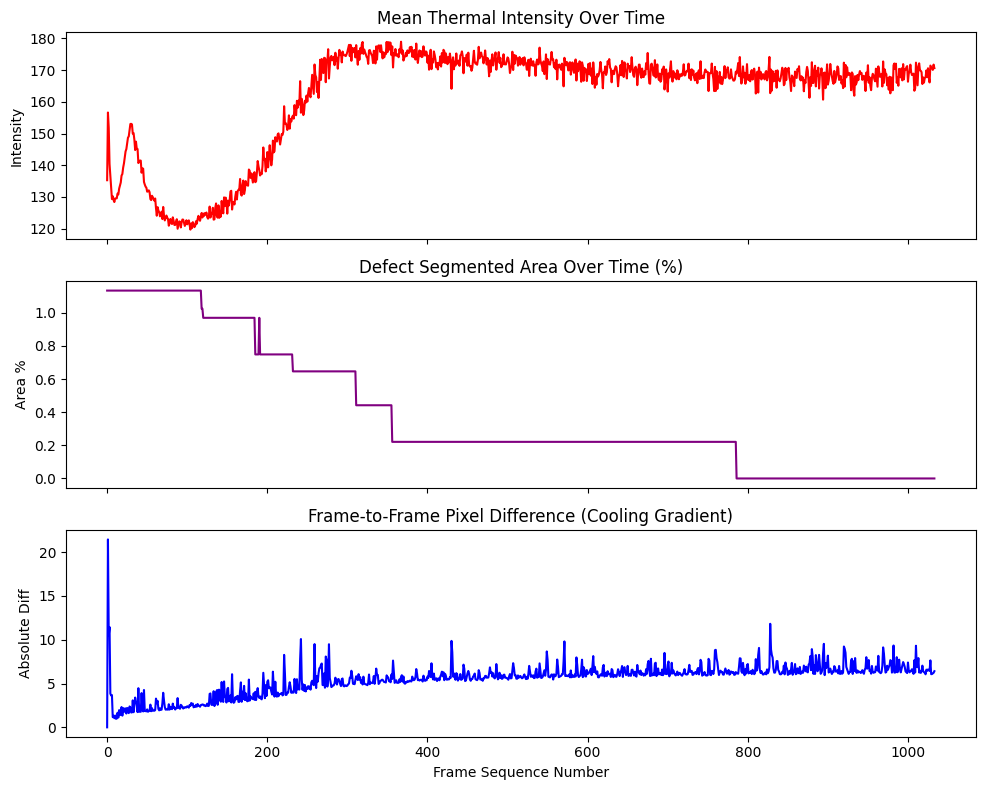

In [29]:
fig1, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig1.canvas.manager.set_window_title('Temporal Dataset Metrics')

axs[0].plot(df['Frame'], df['Mean_Intensity'], color='red')
axs[0].set_title('Mean Thermal Intensity Over Time')
axs[0].set_ylabel('Intensity')

axs[1].plot(df['Frame'], df['Defect_Percentage'], color='purple')
axs[1].set_title('Defect Segmented Area Over Time (%)')
axs[1].set_ylabel('Area %')

axs[2].plot(df['Frame'], df['Frame_Diff'], color='blue')
axs[2].set_title('Frame-to-Frame Pixel Difference (Cooling Gradient)')
axs[2].set_ylabel('Absolute Diff')
axs[2].set_xlabel('Frame Sequence Number')
plt.tight_layout()

In [10]:
print(f"Connected Components - Average distinct defects found per frame: {df['Defect_Count'].mean():.2f}")
print(f"Average Size of individual defects: {df['Avg_Defect_Size'].mean():.2f} pixels")
print(f"Defect Spatial Movement - Centroid Std Dev X: {df['Centroid_X'].std():.2f}, Y: {df['Centroid_Y'].std():.2f}")

Connected Components - Average distinct defects found per frame: 2.45
Average Size of individual defects: 79.67 pixels
Defect Spatial Movement - Centroid Std Dev X: 72.67, Y: 35.80


In [11]:
correlation = df['Mean_Intensity'].corr(df['Defect_Percentage'])
print(f"Correlation between Thermal Intensity and Defect Area %: {correlation:.4f}")

Correlation between Thermal Intensity and Defect Area %: -0.8319


In [30]:
print(df[['Mean_Intensity', 'Defect_Percentage', 'Defect_Count', 'Frame_Diff']].describe().to_markdown())

|       |   Mean_Intensity |   Defect_Percentage |   Defect_Count |   Frame_Diff |
|:------|-----------------:|--------------------:|---------------:|-------------:|
| count |         1034     |         1034        |     1034       |   1034       |
| mean  |          161.923 |            0.387144 |        2.45455 |      5.51157 |
| std   |           16.521 |            0.380508 |        2.92308 |      1.73001 |
| min   |          119.657 |            0        |        0       |      0       |
| 25%   |          162.702 |            0.22098  |        1       |      4.92644 |
| 50%   |          168.784 |            0.22098  |        1       |      5.92226 |
| 75%   |          172.051 |            0.646504 |        4       |      6.3629  |
| max   |          178.975 |            1.13412  |        9       |     21.443   |


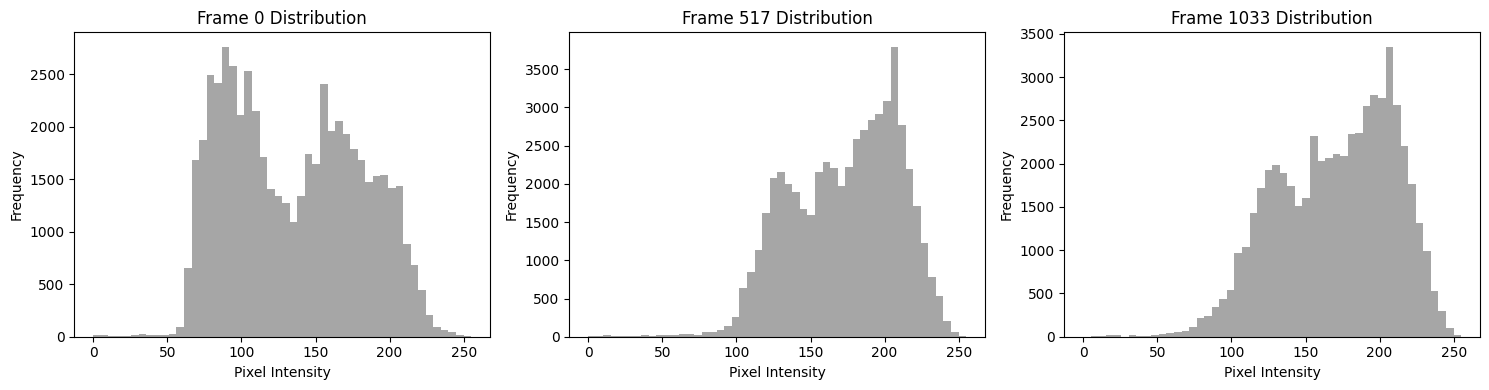

In [13]:
fig2, ax2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.canvas.manager.set_window_title('Pixel Intensity Histograms')
samples_for_hist = [0, total_orig//2, total_orig-1]

for idx, p_idx in enumerate(samples_for_hist):
    img = cv2.imread(os.path.join(orig_dir, orig_files[p_idx]), cv2.IMREAD_GRAYSCALE)
    ax2[idx].hist(img.ravel(), bins=50, color='gray', alpha=0.7)
    ax2[idx].set_title(f'Frame {p_idx} Distribution')
    ax2[idx].set_xlabel('Pixel Intensity')
    ax2[idx].set_ylabel('Frequency')
plt.tight_layout()

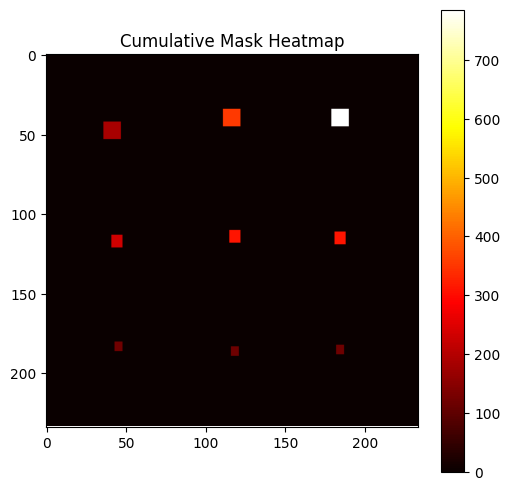

In [14]:
fig3, ax3 = plt.subplots(figsize=(6, 6))
fig3.canvas.manager.set_window_title('Spatial Defect Density Map')
cax = ax3.imshow(mask_accumulator, cmap='hot')
ax3.set_title("Cumulative Mask Heatmap")
fig3.colorbar(cax)

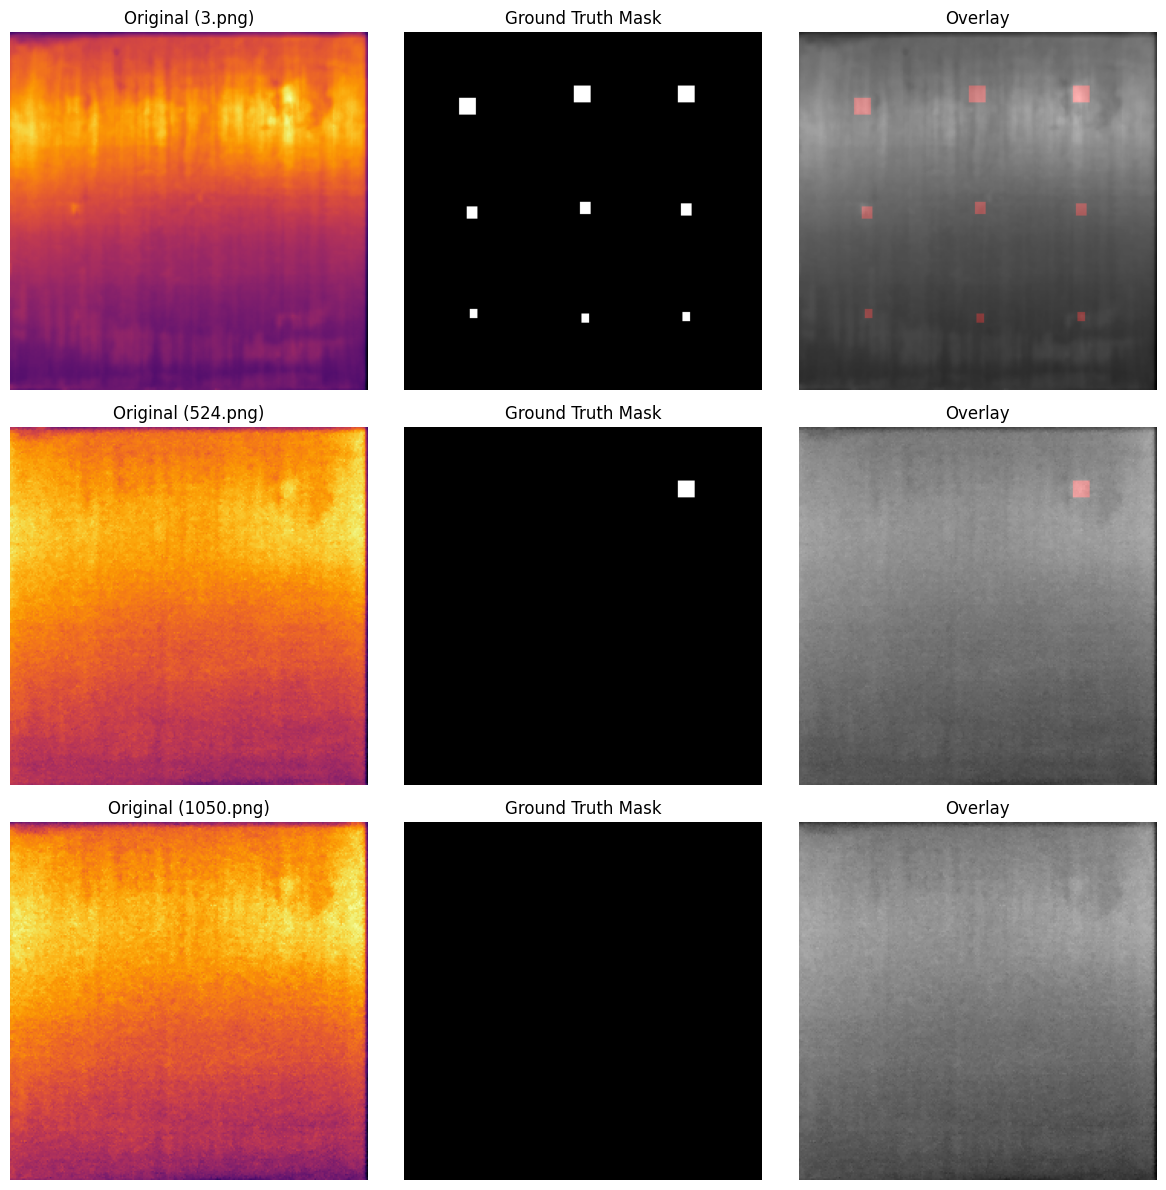

In [15]:
sample_size = 3
sample_indices = np.linspace(0, total_orig - 1, sample_size, dtype=int)
fig4, axes = plt.subplots(sample_size, 3, figsize=(12, 4 * sample_size))
fig4.canvas.manager.set_window_title('Visual Overlay Sequence')

for i, idx in enumerate(sample_indices):
    filename = orig_files[idx]
    orig_img = cv2.imread(os.path.join(orig_dir, filename), cv2.IMREAD_GRAYSCALE)
    mask_img = cv2.imread(os.path.join(mask_dir, filename), cv2.IMREAD_GRAYSCALE)
    
    orig_color = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2BGR) 
    red_overlay = np.zeros_like(orig_color)
    red_overlay[mask_img > 0] = [0, 0, 255] 
    overlay_img = cv2.addWeighted(orig_color, 0.7, red_overlay, 0.3, 0)

    axes[i][0].imshow(orig_img, cmap='inferno')
    axes[i][0].set_title(f"Original ({filename})")
    axes[i][0].axis('off')

    axes[i][1].imshow(mask_img, cmap='gray')
    axes[i][1].set_title("Ground Truth Mask")
    axes[i][1].axis('off')

    axes[i][2].imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
    axes[i][2].set_title("Overlay")
    axes[i][2].axis('off')

plt.tight_layout()

# Show all generated plots
plt.show()

In [16]:
df_contrast = pd.DataFrame(contrast_records)
peak_contrast_idx = df_contrast.loc[df_contrast['Absolute_Contrast'].idxmax(), 'Frame']
peak_filename = orig_files[int(peak_contrast_idx)]
peak_img = cv2.imread(os.path.join(orig_dir, peak_filename), cv2.IMREAD_GRAYSCALE)

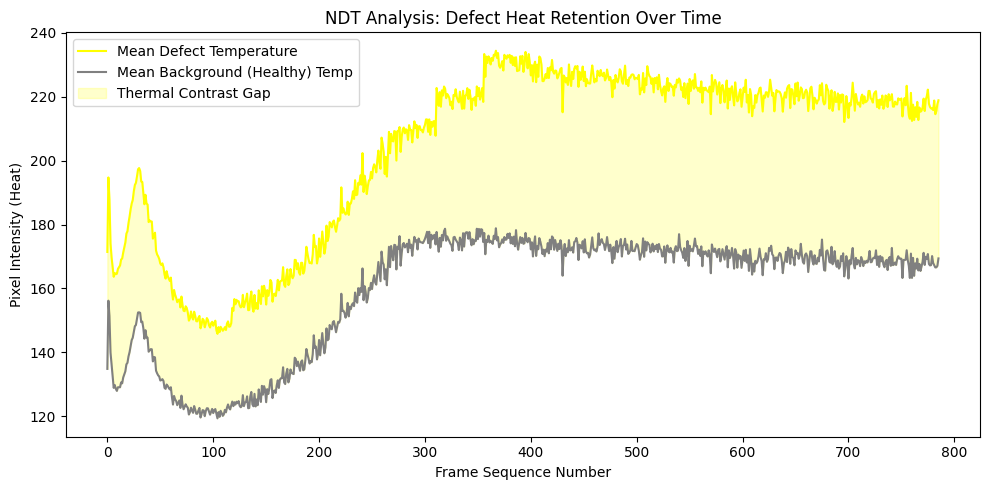

In [17]:
fig1, ax1 = plt.subplots(figsize=(10, 5))
fig1.canvas.manager.set_window_title('Absolute Thermal Contrast')

ax1.plot(df_contrast['Frame'], df_contrast['Defect_Heat'], color='yellow', label='Mean Defect Temperature')
ax1.plot(df_contrast['Frame'], df_contrast['Background_Heat'], color='gray', label='Mean Background (Healthy) Temp')
ax1.fill_between(df_contrast['Frame'], df_contrast['Background_Heat'], df_contrast['Defect_Heat'], color='yellow', alpha=0.2, label='Thermal Contrast Gap')

ax1.set_title('NDT Analysis: Defect Heat Retention Over Time')
ax1.set_xlabel('Frame Sequence Number')
ax1.set_ylabel('Pixel Intensity (Heat)')
ax1.legend()
plt.tight_layout()

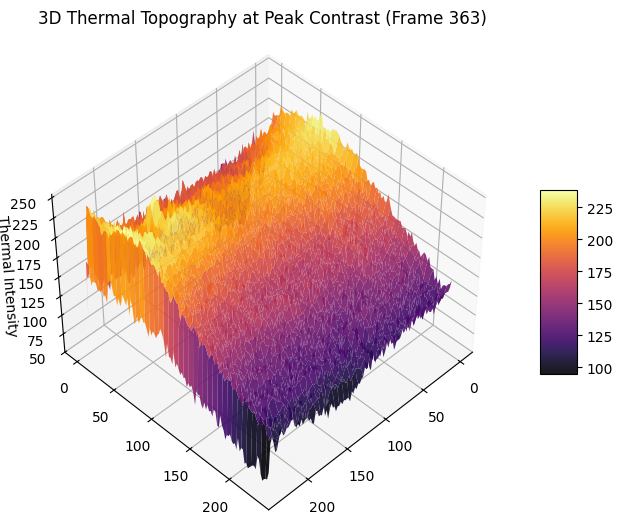

In [18]:
fig2 = plt.figure(figsize=(12, 6))
fig2.canvas.manager.set_window_title('3D Thermal Surface Map')
ax2 = fig2.add_subplot(111, projection='3d')

downscale_factor = 2 # Downsample the image slightly for a smoother 3D plot
h, w = peak_img.shape
X = np.arange(0, w, downscale_factor)
Y = np.arange(0, h, downscale_factor)
X, Y = np.meshgrid(X, Y)
Z = peak_img[::downscale_factor, ::downscale_factor]

surf = ax2.plot_surface(X, Y, Z, cmap='inferno', edgecolor='none', alpha=0.9)
ax2.set_title(f'3D Thermal Topography at Peak Contrast (Frame {int(peak_contrast_idx)})', pad=20)
ax2.set_zlabel('Thermal Intensity', labelpad=0)
fig2.colorbar(surf, shrink=0.4, aspect=5)
ax2.view_init(elev=45, azim=45)

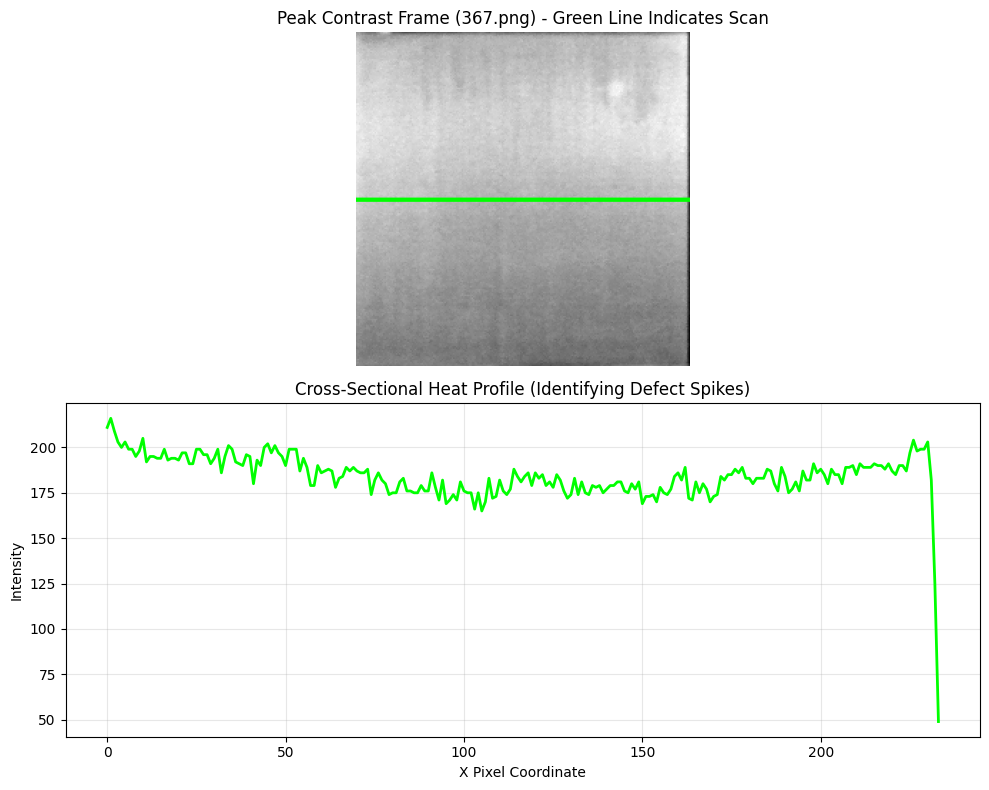

In [19]:
fig3, ax3 = plt.subplots(2, 1, figsize=(10, 8))
fig3.canvas.manager.set_window_title('Spatial Profile (Line Scan)')

middle_row_y = h // 2
line_profile = peak_img[middle_row_y, :]

img_with_line = cv2.cvtColor(peak_img, cv2.COLOR_GRAY2BGR)
cv2.line(img_with_line, (0, middle_row_y), (w, middle_row_y), (0, 255, 0), 2)

ax3[0].imshow(cv2.cvtColor(img_with_line, cv2.COLOR_BGR2RGB))
ax3[0].set_title(f"Peak Contrast Frame ({peak_filename}) - Green Line Indicates Scan")
ax3[0].axis('off')

ax3[1].plot(line_profile, color='lime', linewidth=2)
ax3[1].set_title('Cross-Sectional Heat Profile (Identifying Defect Spikes)')
ax3[1].set_ylabel('Intensity')
ax3[1].set_xlabel('X Pixel Coordinate')
ax3[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
from sklearn.decomposition import PCA

h, w = cv2.imread(os.path.join(orig_dir, orig_files[0]), cv2.IMREAD_GRAYSCALE).shape
thermal_cube = np.zeros((total_orig, h, w), dtype=np.float32)

for i, filename in enumerate(orig_files):
    img = cv2.imread(os.path.join(orig_dir, filename), cv2.IMREAD_GRAYSCALE)
    thermal_cube[i, :, :] = img

print(f"Loaded Thermal Cube with shape: {thermal_cube.shape}")

Loaded Thermal Cube with shape: (1034, 234, 234)


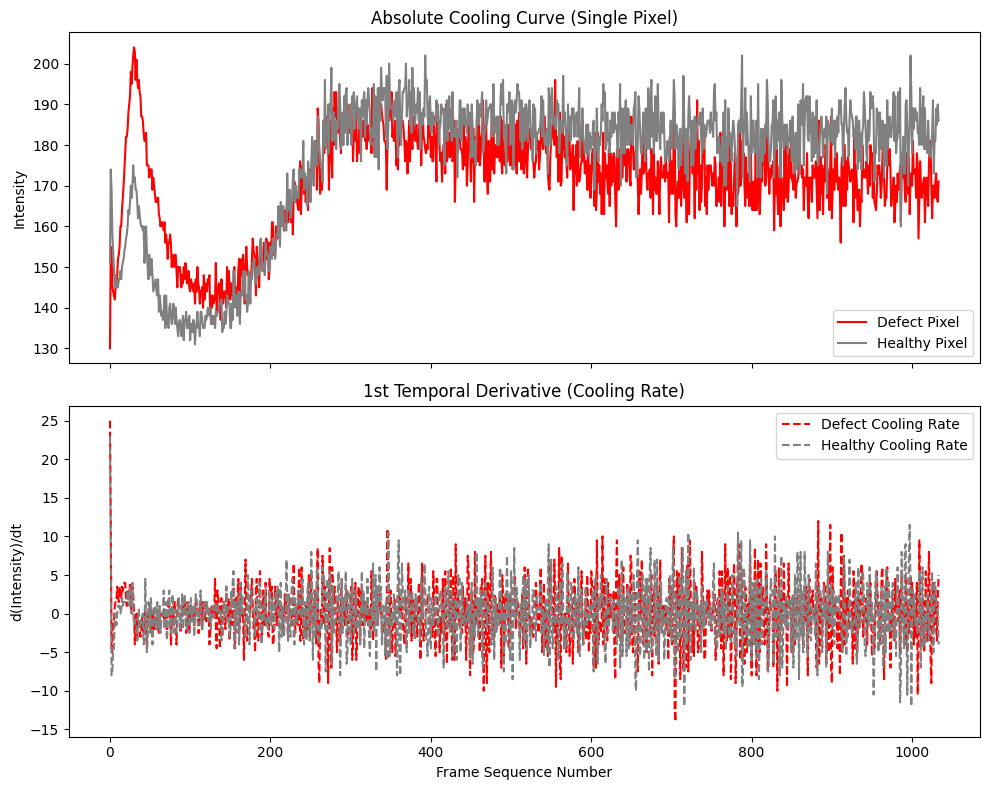

In [21]:
defect_y, defect_x = h // 2, w // 2
healthy_y, healthy_x = 10, 10

defect_profile = thermal_cube[:, defect_y, defect_x]
healthy_profile = thermal_cube[:, healthy_y, healthy_x]

defect_deriv = np.gradient(defect_profile)
healthy_deriv = np.gradient(healthy_profile)

fig5, ax5 = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig5.canvas.manager.set_window_title('Single Pixel Thermodynamics')

ax5[0].plot(defect_profile, color='red', label='Defect Pixel')
ax5[0].plot(healthy_profile, color='gray', label='Healthy Pixel')
ax5[0].set_title('Absolute Cooling Curve (Single Pixel)')
ax5[0].set_ylabel('Intensity')
ax5[0].legend()

ax5[1].plot(defect_deriv, color='red', linestyle='--', label='Defect Cooling Rate')
ax5[1].plot(healthy_deriv, color='gray', linestyle='--', label='Healthy Cooling Rate')
ax5[1].set_title('1st Temporal Derivative (Cooling Rate)')
ax5[1].set_ylabel('d(Intensity)/dt')
ax5[1].set_xlabel('Frame Sequence Number')
ax5[1].legend()

plt.tight_layout()
plt.show()

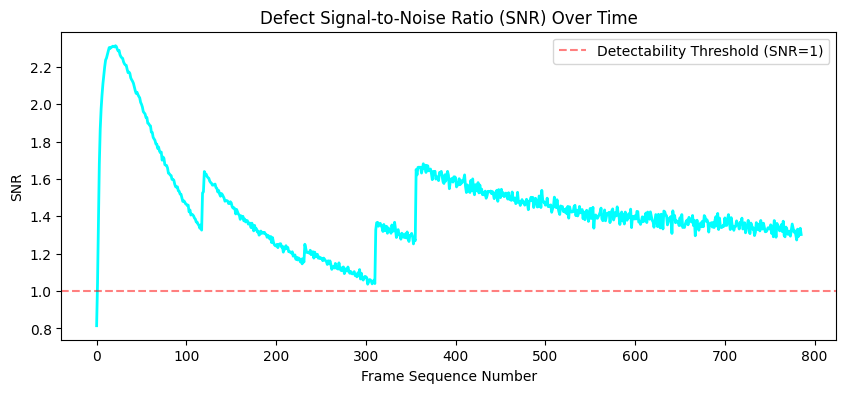

In [22]:
snr_records = []

for i in range(total_orig):
    orig_img = thermal_cube[i]
    mask_img = cv2.imread(os.path.join(mask_dir, orig_files[i]), cv2.IMREAD_GRAYSCALE)
    
    if np.any(mask_img > 0):
        mean_defect = np.mean(orig_img[mask_img > 0])
        mean_bg = np.mean(orig_img[mask_img == 0])
        std_bg = np.std(orig_img[mask_img == 0])
        
        snr = (mean_defect - mean_bg) / (std_bg + 1e-6) 
        snr_records.append({'Frame': i, 'SNR': snr})

df_snr = pd.DataFrame(snr_records)

fig6, ax6 = plt.subplots(figsize=(10, 4))
fig6.canvas.manager.set_window_title('SNR Evolution')
ax6.plot(df_snr['Frame'], df_snr['SNR'], color='cyan', linewidth=2)
ax6.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Detectability Threshold (SNR=1)')
ax6.set_title('Defect Signal-to-Noise Ratio (SNR) Over Time')
ax6.set_xlabel('Frame Sequence Number')
ax6.set_ylabel('SNR')
ax6.legend()
plt.show()

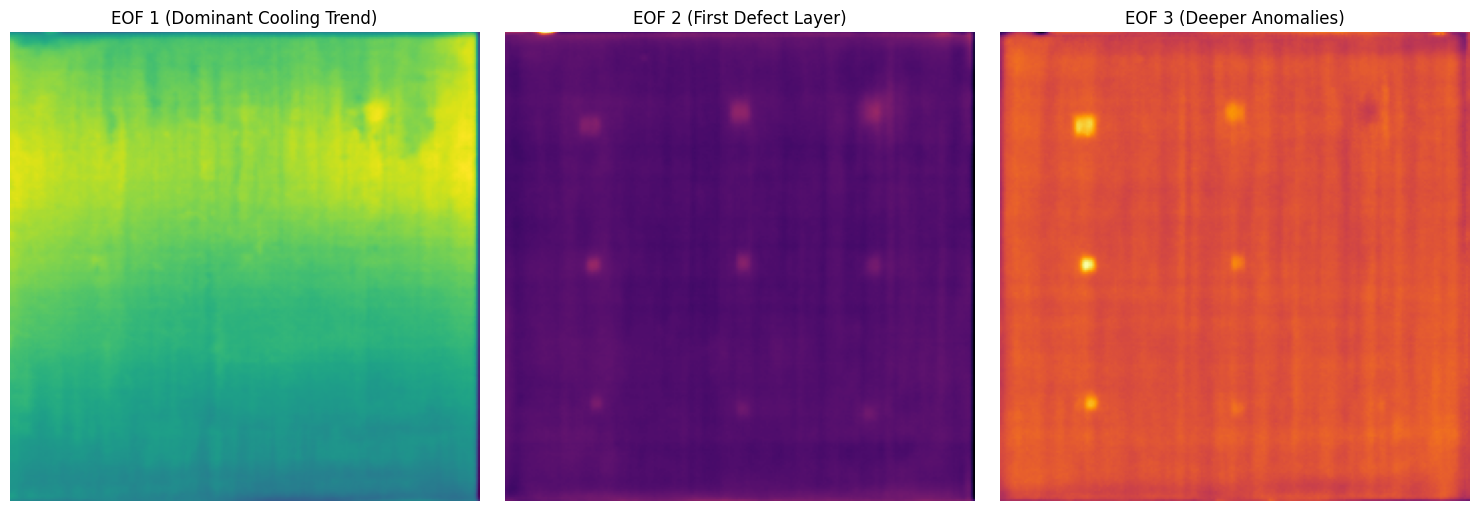

In [23]:
flattened_cube = thermal_cube.reshape(total_orig, -1)

pca = PCA(n_components=3)
components = pca.fit_transform(flattened_cube.T) # Transpose to find spatial components

pc1_img = components[:, 0].reshape(h, w)
pc2_img = components[:, 1].reshape(h, w)
pc3_img = components[:, 2].reshape(h, w)

fig7, axes = plt.subplots(1, 3, figsize=(15, 5))
fig7.canvas.manager.set_window_title('Principal Component Thermography')

axes[0].imshow(pc1_img, cmap='viridis')
axes[0].set_title('EOF 1 (Dominant Cooling Trend)')
axes[0].axis('off')

axes[1].imshow(pc2_img, cmap='inferno')
axes[1].set_title('EOF 2 (First Defect Layer)')
axes[1].axis('off')

axes[2].imshow(pc3_img, cmap='inferno')
axes[2].set_title('EOF 3 (Deeper Anomalies)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

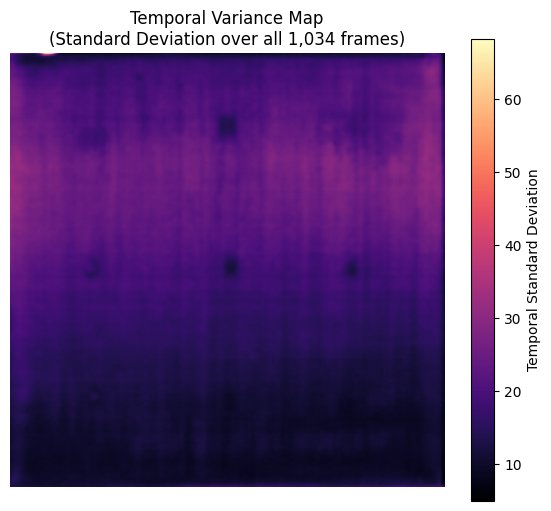

In [24]:
variance_map = np.std(thermal_cube, axis=0)

fig8, ax8 = plt.subplots(figsize=(7, 6))
fig8.canvas.manager.set_window_title('Temporal Variance Map')
cax = ax8.imshow(variance_map, cmap='magma')
ax8.set_title("Temporal Variance Map\n(Standard Deviation over all 1,034 frames)")
ax8.axis('off')
fig8.colorbar(cax, label='Temporal Standard Deviation')
plt.show()

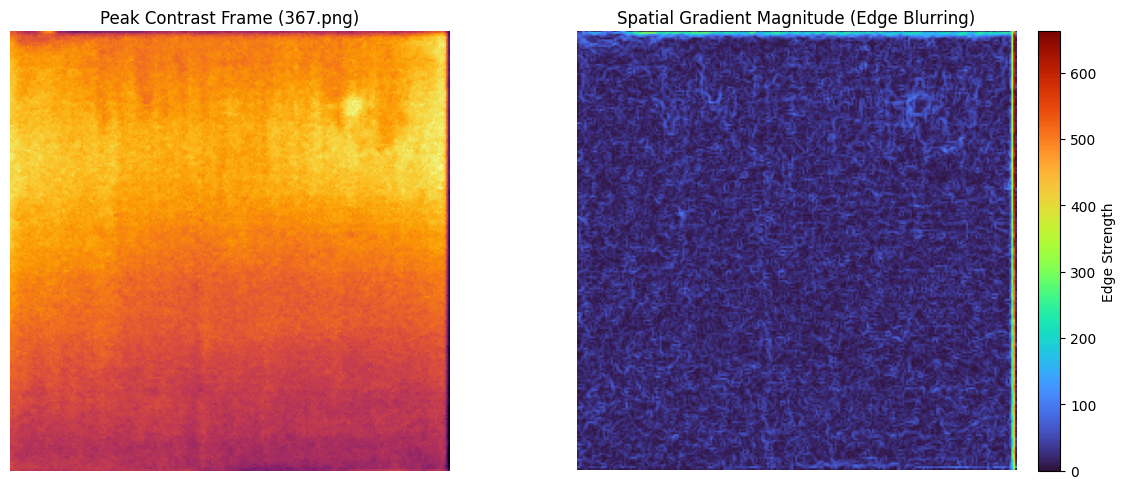

In [31]:
peak_float = peak_img.astype(np.float32)

grad_x = cv2.Sobel(peak_float, cv2.CV_32F, 1, 0, ksize=3)
grad_y = cv2.Sobel(peak_float, cv2.CV_32F, 0, 1, ksize=3)
gradient_magnitude = cv2.magnitude(grad_x, grad_y)

fig9, ax9 = plt.subplots(1, 2, figsize=(12, 5))
fig9.canvas.manager.set_window_title('Spatial Gradient Analysis')

ax9[0].imshow(peak_img, cmap='inferno')
ax9[0].set_title(f'Peak Contrast Frame ({peak_filename})')
ax9[0].axis('off')

cax = ax9[1].imshow(gradient_magnitude, cmap='turbo')
ax9[1].set_title('Spatial Gradient Magnitude (Edge Blurring)')
ax9[1].axis('off')
fig9.colorbar(cax, ax=ax9[1], fraction=0.046, pad=0.04, label='Edge Strength')

plt.tight_layout()
plt.show()